In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.metrics import roc_auc_score, roc_curve

try:
    import mplhep as hep
    plt.style.use(hep.style.CMS)
except Exception:
    pass

OUTPUT_DIR = Path('.')
DF_PATH = OUTPUT_DIR / 'training_oof_scores.parquet'
SCORE_COL = 'oof_score'
WEIGHT_COL = 'balanced_Weight'

type_label_map = {
    0: 'GGJ/GJ/DDQCD',
    1: 'TTG/TTGG',
    2: 'Unmatched-Signal',
    3: 'ggH',
    4: 'ttH/bbH',
    5: 'VH',
    6: 'VBFH',
}


In [2]:
df_all = pd.read_parquet(DF_PATH)
df_all['Type'] = df_all['Type'].astype(int)

print(df_all.shape)
display(
    df_all.groupby(['label', 'Type', 'process'], dropna=False)
    .agg(
        n=('label', 'size'),
        eventWeight_sum=('eventWeight', 'sum'),
        balancedWeight_sum=(WEIGHT_COL, 'sum'),
    )
    .reset_index()
)
display(
    df_all.groupby(['label', 'Type', 'year'], dropna=False)
    .size()
    .rename('n')
    .reset_index()
)


(261682, 41)


,label,Type,process,n,eventWeight_sum,balancedWeight_sum
0,0.0,0,QCD,6267,324.641824,162.320912
1,0.0,1,TTG,45246,38.144680,19.072340
2,0.0,2,signal,6706,0.390402,5.293484
3,0.0,3,ggH,1362,0.390402,5.293484
4,0.0,4,bbH,117,0.015544,0.210758
5,0.0,4,ttH,52977,11.872558,160.980609
6,0.0,5,VH,1929,0.645337,8.750161
7,0.0,6,VBFH,235,0.063777,0.864756
8,1.0,-1,signal,146843,0.586653,362.786504


,label,Type,year,n
0,0.0,0,2016post,404
1,0.0,0,2016pre,420
2,0.0,0,2017,529
3,0.0,0,2018,584
4,0.0,0,2024,687
5,0.0,0,2025,728
6,0.0,0,2223,2915
7,0.0,1,2016post,3360
8,0.0,1,2016pre,2911
9,0.0,1,2017,5303


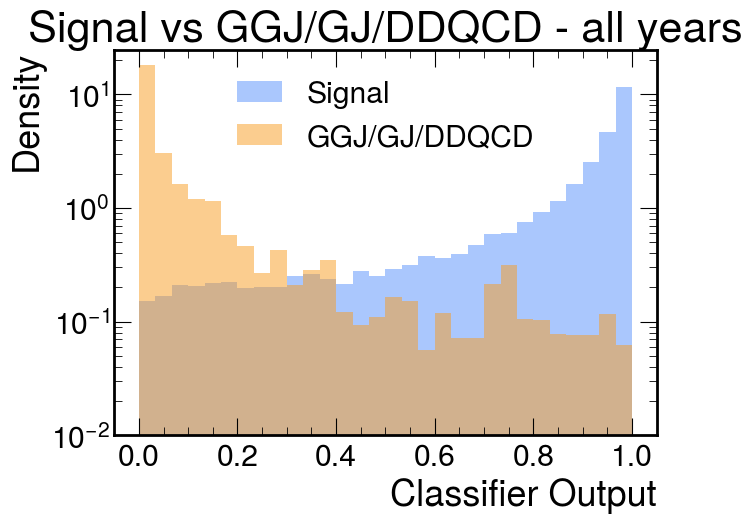

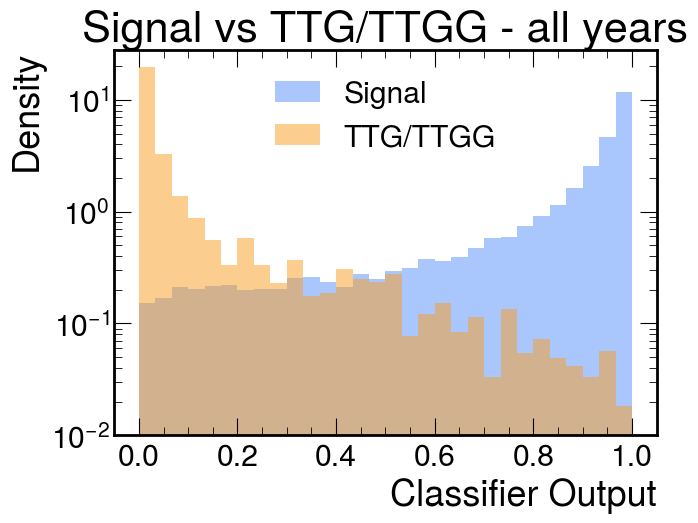

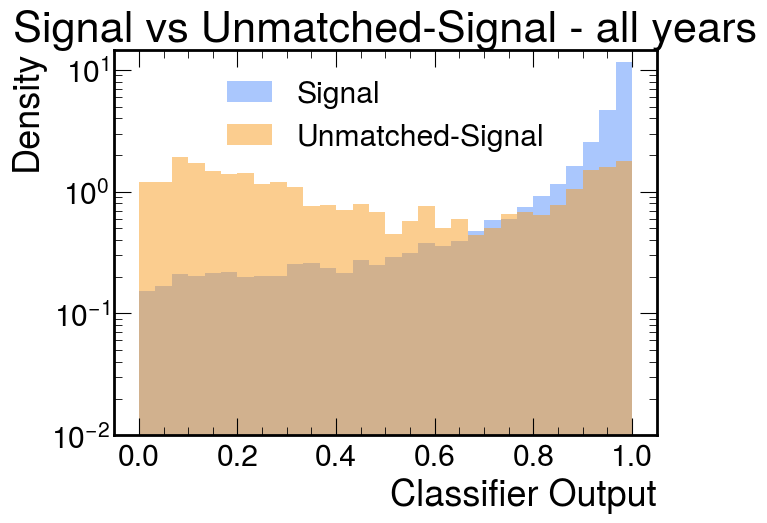

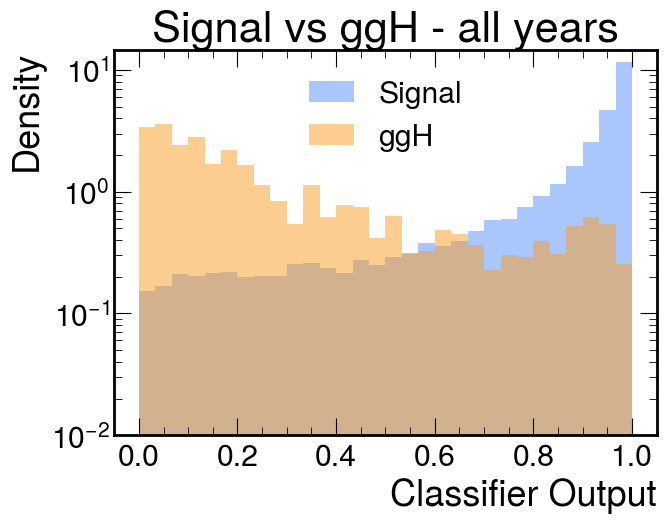

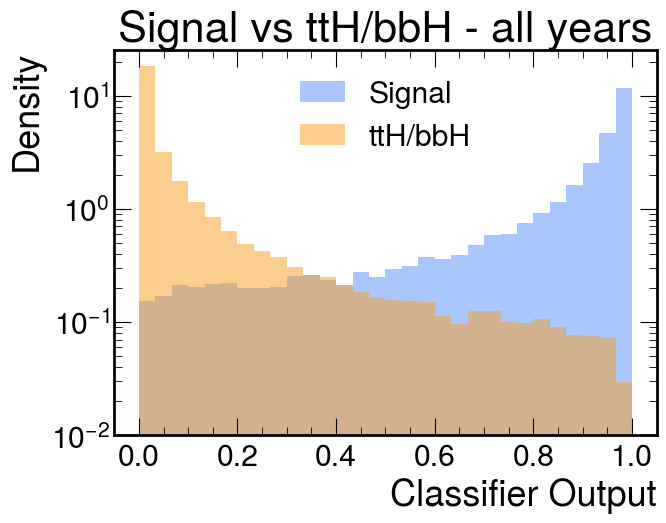

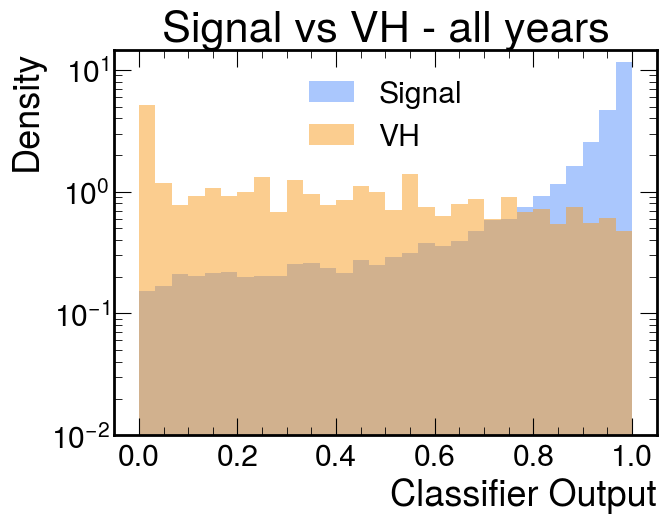

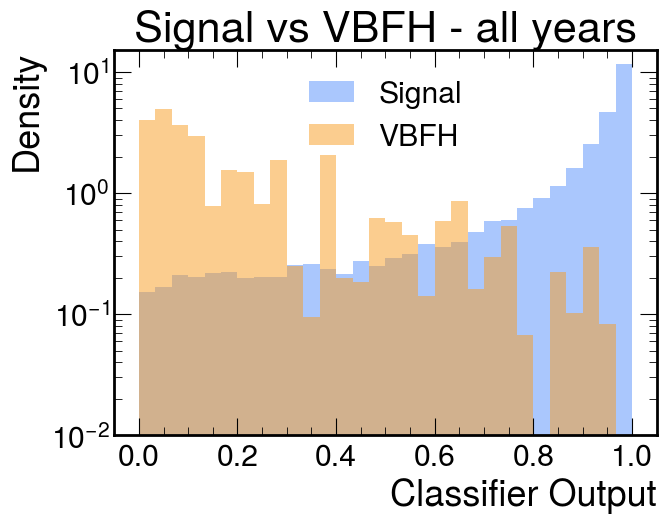

In [3]:
def clean_weights(df, weight_col=WEIGHT_COL, use_abs_weight=True):
    w = df[weight_col].to_numpy(dtype=float)
    if use_abs_weight:
        w = np.abs(w)
    return np.nan_to_num(w, nan=0.0, posinf=0.0, neginf=0.0)


def plot_signal_vs_bkg_score(df, bkg_type, bins=30, score_col=SCORE_COL):
    signal = df[df['Type'] == -1]
    bkg = df[df['Type'] == bkg_type]
    label = type_label_map[bkg_type]

    plt.figure(figsize=(7, 5))
    plt.hist(
        signal[score_col], bins=bins, range=(0, 1), histtype='bar', density=True,
        alpha=0.5, label='Signal', weights=clean_weights(signal)
    )
    plt.hist(
        bkg[score_col], bins=bins, range=(0, 1), histtype='bar', density=True,
        alpha=0.5, label=label, weights=clean_weights(bkg)
    )
    plt.yscale('log')
    plt.ylim(1e-2, None)
    plt.xlabel('Classifier Output')
    plt.ylabel('Density')
    plt.title(f'Signal vs {label} - all years')
    plt.legend()
    plt.show()


for bkg_type in sorted(type_label_map):
    plot_signal_vs_bkg_score(df_all, bkg_type)


In [4]:
def auc_per_bkg_type(df, score_col=SCORE_COL, weight_col=WEIGHT_COL):
    rows = []
    for bkg_type, bkg_name in type_label_map.items():
        mask = (df['Type'] == -1) | (df['Type'] == bkg_type)
        sub = df.loc[mask].copy()
        y = sub['label'].to_numpy(dtype=int)
        score = sub[score_col].to_numpy(dtype=float)
        weight = clean_weights(sub, weight_col=weight_col)
        auc = roc_auc_score(y, score, sample_weight=weight)
        rows.append({
            'Type': bkg_type,
            'Process': bkg_name,
            'n_signal': int((sub['Type'] == -1).sum()),
            'n_bkg': int((sub['Type'] == bkg_type).sum()),
            'AUROC': auc,
        })
    return pd.DataFrame(rows)


auc_table = auc_per_bkg_type(df_all)
display(auc_table)


,Type,Process,n_signal,n_bkg,AUROC
0,0,GGJ/GJ/DDQCD,146843,6267,0.975762
1,1,TTG/TTGG,146843,45246,0.981578
2,2,Unmatched-Signal,146843,6706,0.825630
3,3,ggH,146843,1362,0.919903
4,4,ttH/bbH,146843,53094,0.978107
5,5,VH,146843,1929,0.884749
6,6,VBFH,146843,235,0.946752


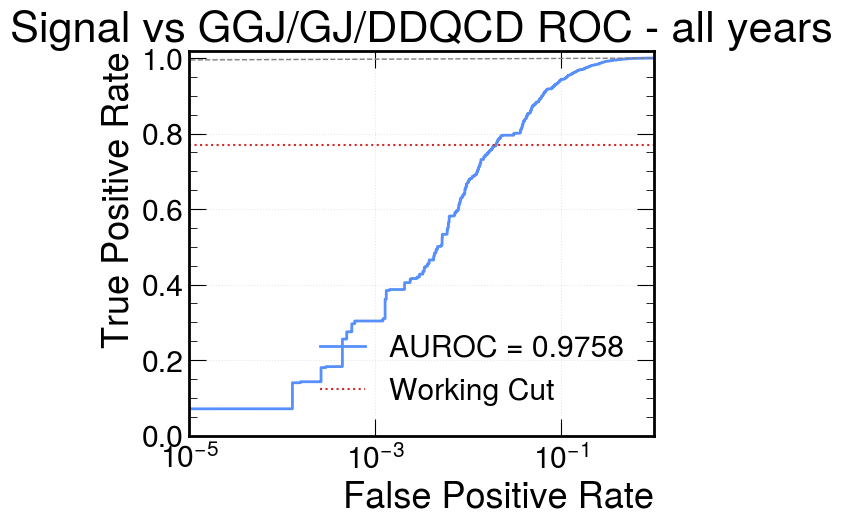

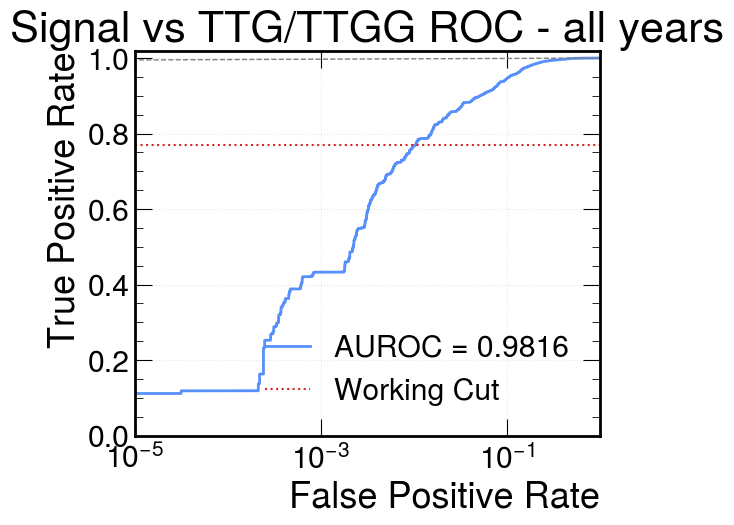

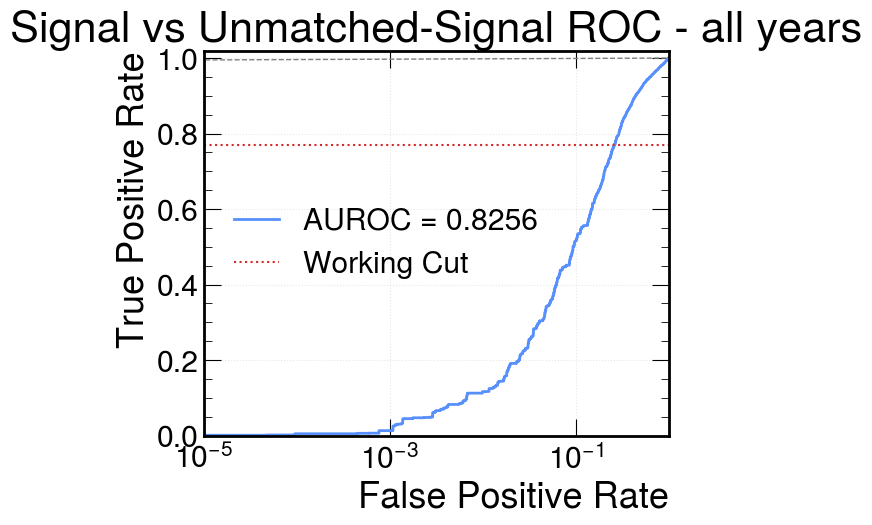

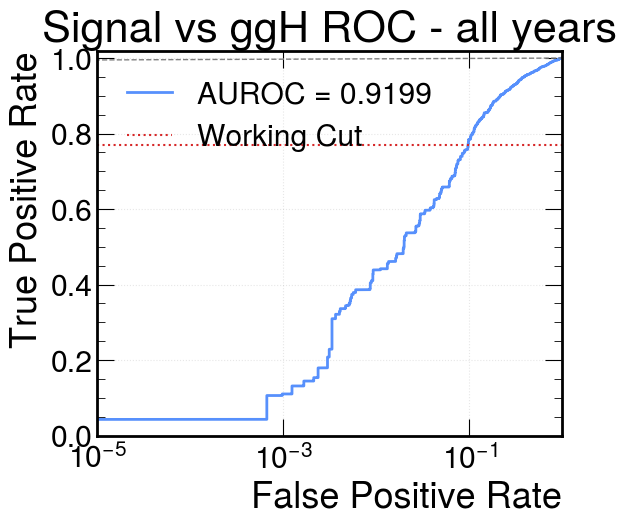

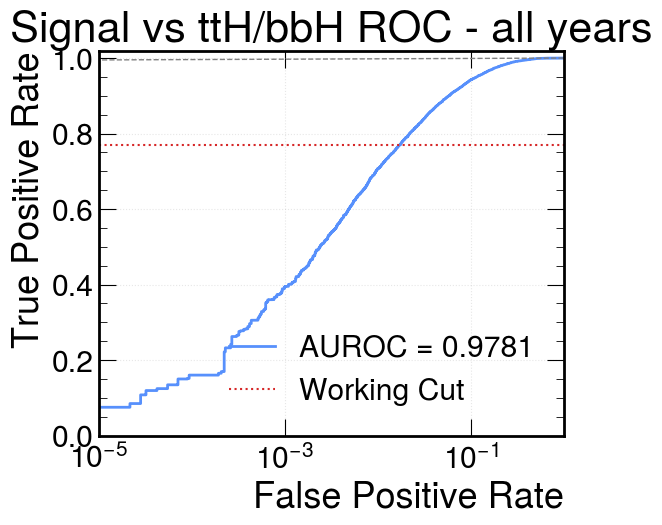

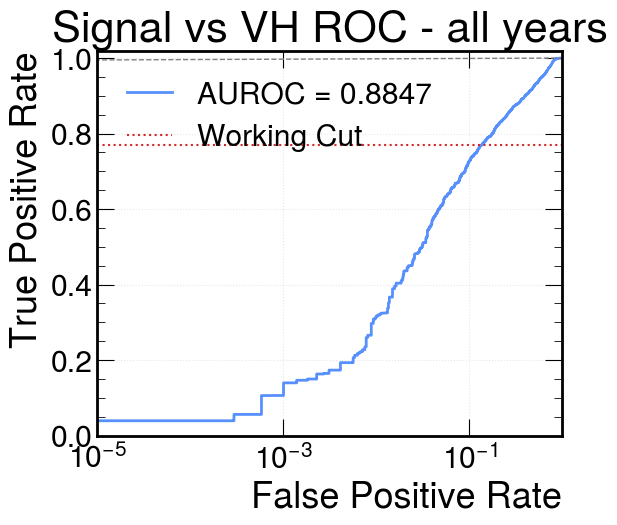

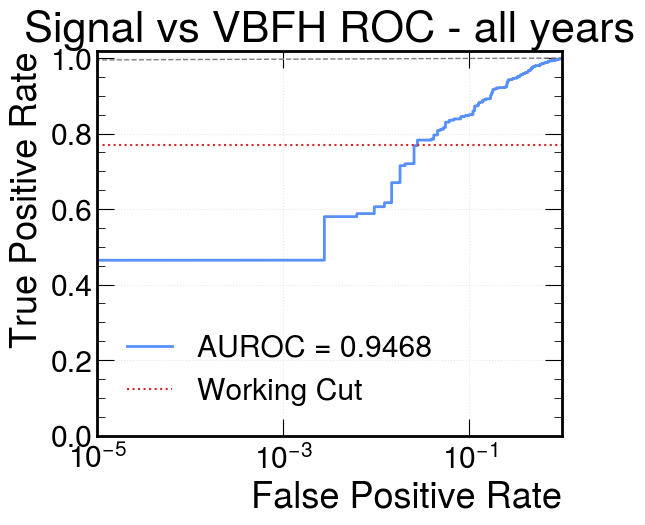

In [5]:
def plot_roc_per_bkg_type(df, score_col=SCORE_COL, weight_col=WEIGHT_COL, logx=True):
    for bkg_type, bkg_name in type_label_map.items():
        mask = (df['Type'] == -1) | (df['Type'] == bkg_type)
        sub = df.loc[mask].copy()
        y = sub['label'].to_numpy(dtype=int)
        score = sub[score_col].to_numpy(dtype=float)
        weight = clean_weights(sub, weight_col=weight_col)

        auc = roc_auc_score(y, score, sample_weight=weight)
        fpr, tpr, _ = roc_curve(y, score, sample_weight=weight)

        plt.figure(figsize=(6, 5))
        plt.plot(fpr, tpr, linewidth=2, label=f'AUROC = {auc:.4f}')
        plt.plot([0, 1], [0, 1], '--', color='gray', linewidth=1)
        plt.axhline(y=0.77, color='tab:red', linestyle=':', label='Working Cut')
        if logx:
            plt.xscale('log')
            plt.xlim(1e-5, 1)
        else:
            plt.xlim(0, 1)
        plt.ylim(0, 1.02)
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'Signal vs {bkg_name} ROC - all years')
        plt.grid(alpha=0.3)
        plt.legend()
        plt.show()


plot_roc_per_bkg_type(df_all, logx=True)


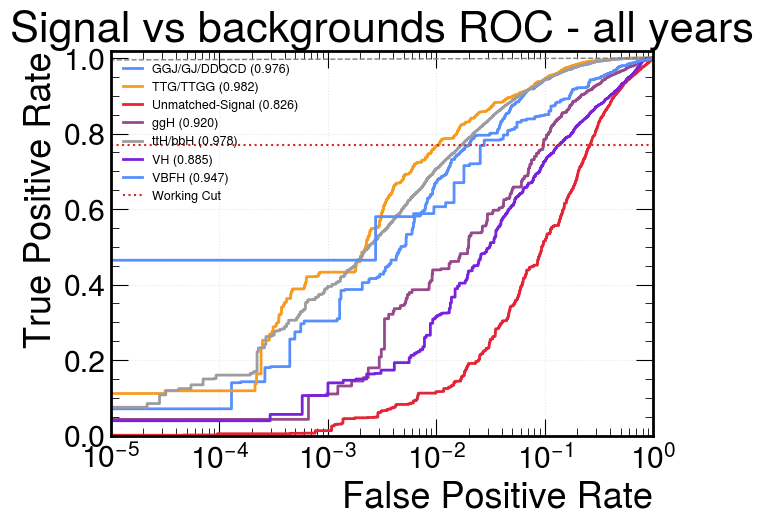

In [6]:
plt.figure(figsize=(7, 5))
for bkg_type, bkg_name in type_label_map.items():
    mask = (df_all['Type'] == -1) | (df_all['Type'] == bkg_type)
    sub = df_all.loc[mask]
    y = sub['label'].to_numpy(dtype=int)
    score = sub[SCORE_COL].to_numpy(dtype=float)
    weight = clean_weights(sub)
    auc = roc_auc_score(y, score, sample_weight=weight)
    fpr, tpr, _ = roc_curve(y, score, sample_weight=weight)
    plt.plot(fpr, tpr, linewidth=2, label=f'{bkg_name} ({auc:.3f})')

plt.plot([0, 1], [0, 1], '--', color='gray', linewidth=1)
plt.axhline(y=0.77, color='tab:red', linestyle=':', label='Working Cut')
plt.xscale('log')
plt.xlim(1e-5, 1)
plt.ylim(0, 1.02)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Signal vs backgrounds ROC - all years')
plt.grid(alpha=0.3)
plt.legend(fontsize=9)
plt.show()


,score_cut,S,B_singleH_SR,B_nonres_100_180,B_nonres_extrap_SR,B_nonres_direct_SR,B_total,S_over_B,S_over_sqrtB,nonres_direct_over_extrap
0,0.0,0.329098,10.304610,159.823648,9.589419,11.952581,19.894029,0.016543,0.073784,1.246434
10,0.1,0.323748,3.097924,36.345704,2.180742,2.876945,5.278666,0.061331,0.140911,1.319250
20,0.2,0.317151,2.199719,22.826164,1.369570,2.008403,3.569289,0.088855,0.167871,1.466448
40,0.4,0.302056,1.232021,13.999370,0.839962,0.811150,2.071983,0.145781,0.209843,0.965699
70,0.7,0.270055,0.474919,8.492489,0.509549,0.299405,0.984468,0.274315,0.272177,0.587589
80,0.8,0.250545,0.320769,3.160970,0.189658,0.297056,0.510427,0.490853,0.350686,1.566272


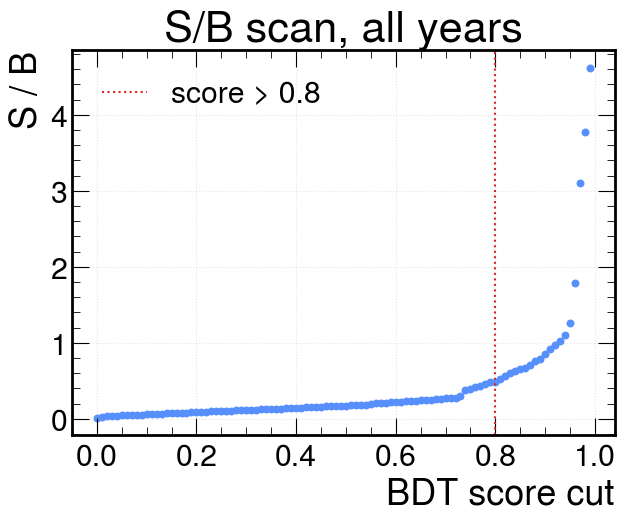

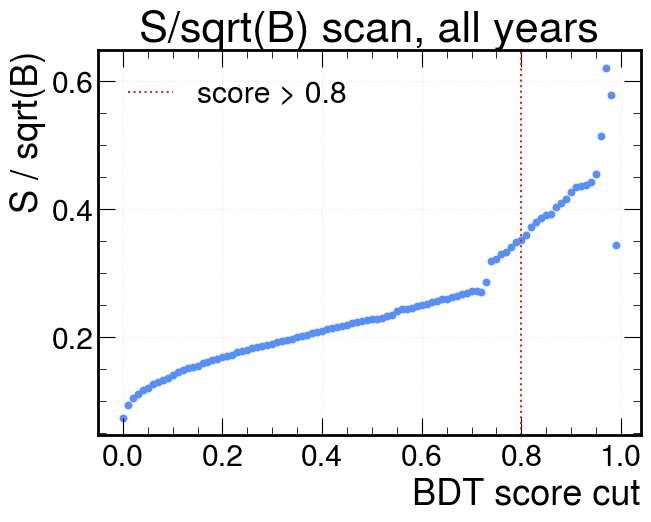

,score_cut,S,B_singleH_SR,B_nonres_extrap_SR,B_nonres_direct_SR,B_total,S_over_B,nonres_direct_over_extrap
50,0.5,0.294320,0.944163,0.731221,0.686360,1.675383,0.175673,0.938650
60,0.6,0.283121,0.691846,0.587847,0.407327,1.279693,0.221242,0.692912
70,0.7,0.270055,0.474919,0.509549,0.299405,0.984468,0.274315,0.587589
80,0.8,0.250545,0.320769,0.189658,0.297056,0.510427,0.490853,1.566272
90,0.9,0.211618,0.156142,0.090300,0.230178,0.246443,0.858690,2.549035


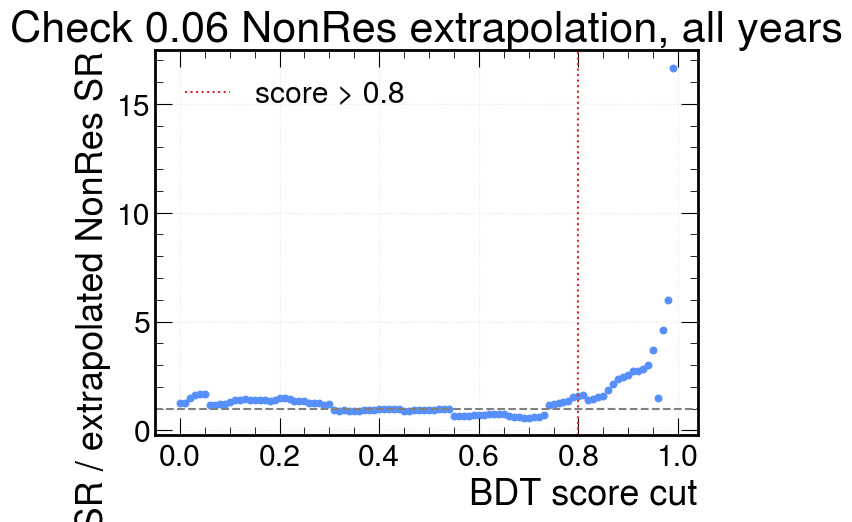

In [7]:
signal_window = (122.5, 127.0)
nonres_mass_range = (100.0, 180.0)
nonres_extrapolation_factor = 0.06
scan_thresholds = np.linspace(0.0, 0.99, 100)

# Signal: only matched signal from the nominal signal batch, valid==1, like the original batch0 logic.
signal_mask_base = (
    (df_all['Type'] == -1)
    & (df_all.get('valid', 1) == 1)
    & (df_all['mass'] > signal_window[0])
    & (df_all['mass'] < signal_window[1])
)

# SingleH-like background follows the notebook grouping: fake/unmatched signal plus ggH/ttH/bbH/VH/VBFH.
singleh_types = [2, 3, 4, 5, 6]
singleh_mask_base = (
    df_all['Type'].isin(singleh_types)
    & (df_all['mass'] > signal_window[0])
    & (df_all['mass'] < signal_window[1])
)

# NonRes is estimated from 100-180 and extrapolated to the signal window by 0.06.
nonres_types = [0, 1]
nonres_sideband_mask_base = (
    df_all['Type'].isin(nonres_types)
    & (df_all['mass'] > nonres_mass_range[0])
    & (df_all['mass'] < nonres_mass_range[1])
)
nonres_direct_sr_mask_base = (
    df_all['Type'].isin(nonres_types)
    & (df_all['mass'] > signal_window[0])
    & (df_all['mass'] < signal_window[1])
)

rows = []
for cut in scan_thresholds:
    score_mask = df_all[SCORE_COL] > cut
    s = df_all.loc[signal_mask_base & score_mask, 'eventWeight'].sum()
    b_singleh = df_all.loc[singleh_mask_base & score_mask, 'eventWeight'].sum()
    b_nonres_100_180 = df_all.loc[nonres_sideband_mask_base & score_mask, 'eventWeight'].sum()
    b_nonres_extrap = b_nonres_100_180 * nonres_extrapolation_factor
    b_nonres_direct_sr = df_all.loc[nonres_direct_sr_mask_base & score_mask, 'eventWeight'].sum()
    b_total = b_singleh + b_nonres_extrap
    rows.append({
        'score_cut': cut,
        'S': s,
        'B_singleH_SR': b_singleh,
        'B_nonres_100_180': b_nonres_100_180,
        'B_nonres_extrap_SR': b_nonres_extrap,
        'B_nonres_direct_SR': b_nonres_direct_sr,
        'B_total': b_total,
        'S_over_B': s / b_total if b_total != 0 else np.nan,
        'S_over_sqrtB': s / np.sqrt(b_total) if b_total > 0 else np.nan,
        'nonres_direct_over_extrap': b_nonres_direct_sr / b_nonres_extrap if b_nonres_extrap != 0 else np.nan,
    })

scan_df = pd.DataFrame(rows)
display(scan_df.loc[np.isclose(scan_df['score_cut'] % 0.1, 0, atol=0.005)])

plt.figure(figsize=(7, 5))
plt.scatter(scan_df['score_cut'], scan_df['S_over_B'], s=22)
plt.axvline(0.8, color='tab:red', linestyle=':', label='score > 0.8')
plt.xlabel('BDT score cut')
plt.ylabel('S / B')
plt.title('S/B scan, all years')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(7, 5))
plt.scatter(scan_df['score_cut'], scan_df['S_over_sqrtB'], s=22)
plt.axvline(0.8, color='tab:red', linestyle=':', label='score > 0.8')
plt.xlabel('BDT score cut')
plt.ylabel('S / sqrt(B)')
plt.title('S/sqrt(B) scan, all years')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

check_points = [0.5, 0.6, 0.7, 0.8, 0.9]
check_df = pd.concat([
    scan_df.iloc[(scan_df['score_cut'] - point).abs().argsort()[:1]]
    for point in check_points
]).copy()
display(check_df[[
    'score_cut', 'S', 'B_singleH_SR', 'B_nonres_extrap_SR', 'B_nonres_direct_SR',
    'B_total', 'S_over_B', 'nonres_direct_over_extrap'
]])

plt.figure(figsize=(7, 5))
plt.scatter(scan_df['score_cut'], scan_df['nonres_direct_over_extrap'], s=22)
plt.axhline(1.0, color='gray', linestyle='--')
plt.axvline(0.8, color='tab:red', linestyle=':', label='score > 0.8')
plt.xlabel('BDT score cut')
plt.ylabel('Direct NonRes SR / extrapolated NonRes SR')
plt.title('Check 0.06 NonRes extrapolation, all years')
plt.grid(alpha=0.3)
plt.legend()
plt.show()


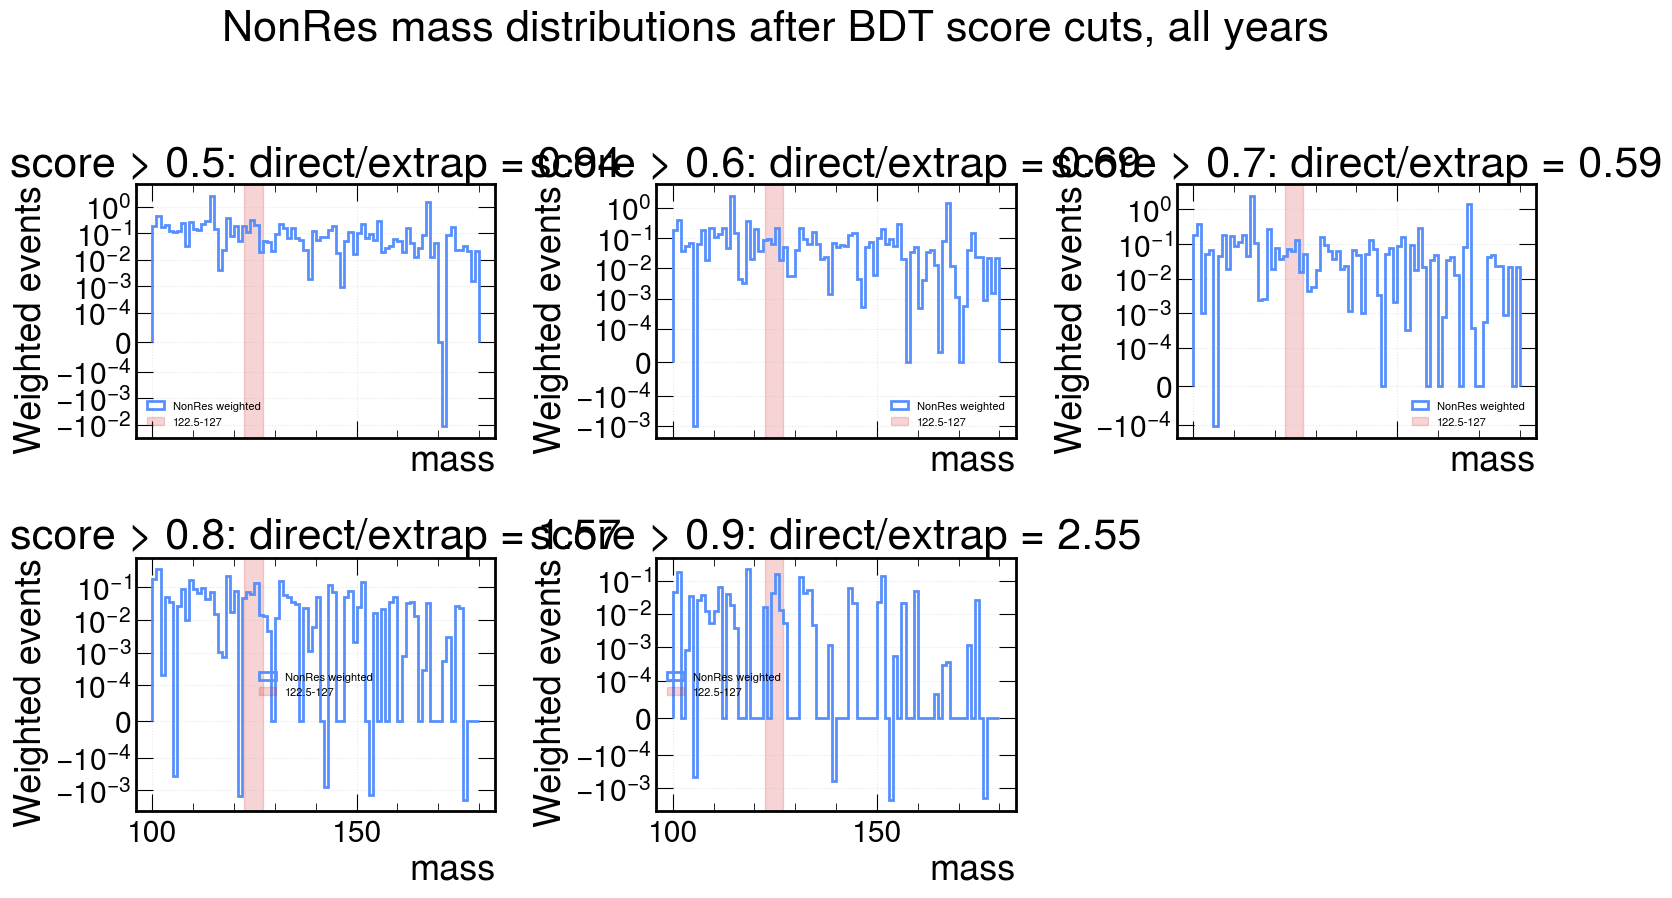

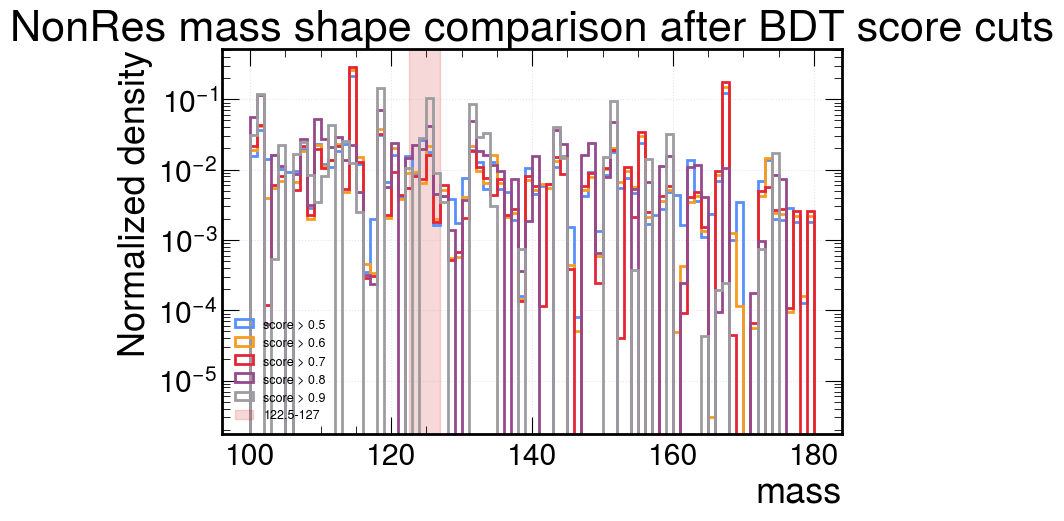

In [8]:
bkg_cuts_to_plot = [0.5, 0.6, 0.7, 0.8, 0.9]
nonres_for_shape = df_all[
    df_all['Type'].isin(nonres_types)
    & (df_all['mass'] > nonres_mass_range[0])
    & (df_all['mass'] < nonres_mass_range[1])
].copy()

fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharex=True)
axes = axes.ravel()

for ax, cut in zip(axes, bkg_cuts_to_plot):
    sub = nonres_for_shape[nonres_for_shape[SCORE_COL] > cut]
    weights = sub['eventWeight'].to_numpy(dtype=float)
    weights = np.nan_to_num(weights, nan=0.0, posinf=0.0, neginf=0.0)

    counts, edges, _ = ax.hist(
        sub['mass'], bins=80, range=nonres_mass_range, histtype='step',
        linewidth=2, weights=weights, label='NonRes weighted'
    )

    direct_sr = sub[
        (sub['mass'] > signal_window[0]) & (sub['mass'] < signal_window[1])
    ]['eventWeight'].sum()
    extrap_sr = sub['eventWeight'].sum() * nonres_extrapolation_factor
    ratio = direct_sr / extrap_sr if extrap_sr != 0 else np.nan

    ax.axvspan(signal_window[0], signal_window[1], color='tab:red', alpha=0.2, label='122.5-127')
    ax.set_yscale('symlog', linthresh=1e-4)
    ax.set_title(f'score > {cut:.1f}: direct/extrap = {ratio:.2f}')
    ax.set_xlabel('mass')
    ax.set_ylabel('Weighted events')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

axes[-1].axis('off')
fig.suptitle('NonRes mass distributions after BDT score cuts, all years', y=1.02)
fig.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
for cut in bkg_cuts_to_plot:
    sub = nonres_for_shape[nonres_for_shape[SCORE_COL] > cut]
    weights = sub['eventWeight'].to_numpy(dtype=float)
    weights = np.nan_to_num(weights, nan=0.0, posinf=0.0, neginf=0.0)
    plt.hist(
        sub['mass'], bins=80, range=nonres_mass_range, histtype='step',
        linewidth=2, density=True, weights=weights, label=f'score > {cut:.1f}'
    )

plt.axvspan(signal_window[0], signal_window[1], color='tab:red', alpha=0.18, label='122.5-127')
plt.yscale('log')
plt.xlabel('mass')
plt.ylabel('Normalized density')
plt.title('NonRes mass shape comparison after BDT score cuts')
plt.grid(alpha=0.3)
plt.legend(fontsize=9)
plt.show()
